# Teacher Capture To Student Observer

Load nominal Gym CartPole capture directories, verify that the rendered PNG frames are already binary, concatenate within-demo one-step transitions across demos, fit a sparse observer model from pixels to the teacher state, refine the learned dynamics under the paper's stability constraint using the teacher-policy controller `K`, and export the combined controller and observer matrices to JSON.

The current nominal workflow uses Gym's native cartpole units directly:

- cart position in meters
- cart velocity in meters per second
- pole angle in radians
- pole angle rate in radians per second
- control in newtons

The notebook still recognizes older step-domain and scaled-step traces when they exist, but the current teacher/student path is the meter-domain nominal CartPole model.

Latest frame directory: `/Users/imaginelenses/code/pixelsToSteps/simulation/captures/collections/crop_padded_train_20260504/demo_20_theta_p12p00_frames`

Collection id: `crop_padded_train_20260504`

Training rollout model: `gym_cartpole_nominal`

Teacher trace unit system: `cartpole`

Observer target: `pixels-to-cartpole-state`

...

First frame from latest demo: `frame_000000.png`

First frame unique values: `[0, 255]`

First frame is binary black/white: `True`

No blur or thresholding is applied. Captured PNG frames are padded to a shared training geometry using top-only and centered-horizontal zero padding. No resizing is applied.

### First Frame Used For Regression

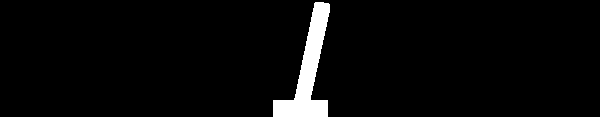

In [17]:
from pathlib import Path
import json

import cv2
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

MAX_TRAINING_DEMOS = None
TRACE_SCHEMAS = {
    "steps": {
        "state_columns": [
            "cart_position_steps",
            "cart_velocity_steps_s",
            "pole_angle_rad",
            "pole_angle_rate_rad_s",
        ],
        "control_column": "applied_control_steps_s",
        "position_column": "cart_position_steps",
        "position_label": "cart position (steps)",
        "control_label": "control (steps/s)",
        "control_units": "steps_per_second",
    },
    "scaled_steps": {
        "state_columns": [
            "cart_position_scaled_steps",
            "cart_velocity_scaled_steps_s",
            "pole_angle_rad",
            "pole_angle_rate_rad_s",
        ],
        "control_column": "applied_control_scaled_steps_s",
        "position_column": "cart_position_scaled_steps",
        "position_label": "cart position (scaled steps)",
        "control_label": "control (scaled steps/s)",
        "control_units": "scaled_steps_per_second",
    },
    "cartpole": {
        "state_columns": [
            "cart_position_m",
            "cart_velocity_m_s",
            "pole_angle_rad",
            "pole_angle_rate_rad_s",
        ],
        "control_column": "applied_control_force_n",
        "position_column": "cart_position_m",
        "position_label": "cart position (m)",
        "control_label": "control force (N)",
        "control_units": "newtons",
    },
}


def resolve_trace_schema(trace: pd.DataFrame) -> tuple[str, dict[str, object]]:
    for unit_system, schema in TRACE_SCHEMAS.items():
        required_columns = set(schema["state_columns"] + [schema["control_column"], "frame_filename"])
        if required_columns.issubset(trace.columns):
            return unit_system, schema
    raise KeyError(
        "Trace CSV does not contain a supported teacher schema. "
        f"Available columns: {trace.columns.tolist()}"
    )


def resolve_unit_value(metadata: dict[str, object], unit_system: str) -> float:
    if unit_system == "scaled_steps":
        unit_value = float(metadata.get("steps_per_unit", 1.0))
        if unit_value <= 0.0:
            raise ValueError(f"Invalid steps_per_unit in metadata: {unit_value!r}")
        return unit_value
    return 1.0


def resolve_observer_artifacts(unit_system: str, rollout_model: str) -> tuple[str, str]:
    if unit_system == "steps" and rollout_model.startswith("gym_cartpole_nominal"):
        return "learned_pixels_to_nominal_steps_observer.json", "pixels-to-nominal-cartpole-steps"
    if unit_system == "steps":
        return "learned_pixels_to_steps_observer.json", "pixels-to-steps"
    if unit_system == "scaled_steps":
        return "learned_pixels_to_scaled_steps_observer.json", "pixels-to-scaled-steps"
    return "learned_pixels_to_cartpole_observer.json", "pixels-to-cartpole-state"


def build_unit_note(unit_system: str, rollout_model: str, metadata: dict[str, object], unit_value: float) -> str:
    if unit_system == "steps" and rollout_model.startswith("gym_cartpole_nominal"):
        meters_per_step = float(metadata.get("meters_per_step", 0.0))
        newtons_per_step_rate = float(metadata.get("newtons_per_step_rate", 0.0))
        return (
            "Nominal CartPole export in step units: cart position and velocity are converted using "
            f"meters_per_step={meters_per_step:.9f}, and step-rate control maps to force through "
            f"newtons_per_step_rate={newtons_per_step_rate:.9f}."
        )
    if unit_system == "scaled_steps":
        if np.isclose(unit_value, 1000.0):
            return "Scaled-step export: 1 observer/control unit = 1000 raw steps (kilostep units)."
        return f"Scaled-step export: 1 observer/control unit = {unit_value:g} raw steps."
    if unit_system == "steps":
        return "Step-domain export: 1 observer/control unit = 1 raw step."
    return "Nominal CartPole export: state uses meters, meters/s, radians, and radians/s; control uses newtons."


def list_capture_frame_dirs() -> list[Path]:
    search_bases = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    candidate_roots: list[Path] = []
    for base in search_bases:
        candidate_roots.extend(
            [
                base / "simulation" / "captures",
                base / "captures",
                base / "python" / "captures",
            ]
        )
    frame_dirs: list[Path] = []
    seen_dirs: set[Path] = set()
    for root in candidate_roots:
        resolved_root = root.resolve()
        if resolved_root in seen_dirs or not resolved_root.exists():
            continue
        seen_dirs.add(resolved_root)
        for metadata_path in resolved_root.rglob("capture_metadata.json"):
            frame_dir = metadata_path.parent
            trace_path = frame_dir / "capture_trace.csv"
            if trace_path.exists() and any(frame_dir.glob("frame_*.png")):
                frame_dirs.append(frame_dir)
    if not frame_dirs:
        raise FileNotFoundError(
            "No complete capture directories were found under simulation/captures, captures, or python/captures."
        )
    return frame_dirs


def load_capture_bundle(frame_dir: Path) -> dict[str, object]:
    metadata_path = frame_dir / "capture_metadata.json"
    trace_path = frame_dir / "capture_trace.csv"
    if not metadata_path.exists():
        raise FileNotFoundError(f"Missing metadata file: {metadata_path}")
    if not trace_path.exists():
        raise FileNotFoundError(f"Missing trace file: {trace_path}")

    metadata = json.loads(metadata_path.read_text(encoding="ascii"))
    trace = pd.read_csv(trace_path)
    unit_system, trace_schema = resolve_trace_schema(trace)
    unit_value = resolve_unit_value(metadata, unit_system)
    frame_paths = [frame_dir / frame_name for frame_name in trace["frame_filename"]]
    if not frame_paths:
        raise FileNotFoundError(f"No frame entries were listed in {trace_path}")

    return {
        "frame_dir": frame_dir,
        "metadata_path": metadata_path,
        "trace_path": trace_path,
        "metadata": metadata,
        "trace": trace,
        "frame_paths": frame_paths,
        "mtime_ns": frame_dir.stat().st_mtime_ns,
        "collection_id": metadata.get("collection_id"),
        "unit_system": unit_system,
        "unit_value": unit_value,
        "trace_schema": trace_schema,
    }


def select_training_bundles(max_training_demos: int | None) -> tuple[list[dict[str, object]], dict[str, object]]:
    bundles = [load_capture_bundle(frame_dir) for frame_dir in list_capture_frame_dirs()]
    latest_bundle = max(bundles, key=lambda bundle: int(bundle["mtime_ns"]))
    latest_metadata = latest_bundle["metadata"]
    target_rollout_model = str(latest_metadata.get("rollout_model", "gym_cartpole_nominal_steps"))
    target_frame_rate_hz = float(latest_metadata["frame_rate_hz"])
    target_unit_system = str(latest_bundle["unit_system"])
    target_unit_value = float(latest_bundle["unit_value"])
    target_collection_id = latest_bundle.get("collection_id")

    matching_bundles = [
        bundle
        for bundle in bundles
        if str(bundle["metadata"].get("rollout_model", "gym_cartpole_nominal_steps")) == target_rollout_model
        and float(bundle["metadata"]["frame_rate_hz"]) == target_frame_rate_hz
        and str(bundle["unit_system"]) == target_unit_system
        and np.isclose(float(bundle["unit_value"]), target_unit_value)
    ]
    if target_collection_id is not None:
        matching_collection_bundles = [
            bundle for bundle in matching_bundles if bundle.get("collection_id") == target_collection_id
        ]
        if matching_collection_bundles:
            matching_bundles = matching_collection_bundles
    matching_bundles.sort(key=lambda bundle: int(bundle["mtime_ns"]))
    if max_training_demos is not None:
        matching_bundles = matching_bundles[-max_training_demos:]
    return matching_bundles, latest_bundle


def display_grayscale_image(title: str, image: np.ndarray) -> None:
    ok, encoded = cv2.imencode(".png", image)
    if not ok:
        raise RuntimeError(f"Failed to encode image for display: {title}")
    display(Markdown(f"### {title}"))
    display(Image(data=encoded.tobytes()))


def load_raw_frame(frame_path: Path) -> np.ndarray:
    frame = cv2.imread(str(frame_path), cv2.IMREAD_GRAYSCALE)
    if frame is None:
        raise RuntimeError(f"Failed to read frame: {frame_path}")
    return frame


def pad_frame_to_target(frame: np.ndarray, target_height_px: int, target_width_px: int) -> np.ndarray:
    frame_height_px, frame_width_px = frame.shape
    if frame_height_px > target_height_px or frame_width_px > target_width_px:
        raise ValueError(
            f"Frame {frame.shape} is larger than target geometry {(target_height_px, target_width_px)}."
        )
    pad_top = max(0, target_height_px - frame_height_px)
    pad_bottom = 0
    pad_left = max(0, (target_width_px - frame_width_px) // 2)
    pad_right = max(0, target_width_px - frame_width_px - pad_left)
    return cv2.copyMakeBorder(
        frame,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        borderType=cv2.BORDER_CONSTANT,
        value=0,
    )


selected_demo_bundles, latest_bundle = select_training_bundles(MAX_TRAINING_DEMOS)
latest_frame_dir = latest_bundle["frame_dir"]
latest_metadata_path = latest_bundle["metadata_path"]
latest_trace_path = latest_bundle["trace_path"]
latest_metadata = latest_bundle["metadata"]
latest_trace = latest_bundle["trace"]
latest_trace_schema = latest_bundle["trace_schema"]
frame_paths = latest_bundle["frame_paths"]
rollout_model = str(latest_metadata.get("rollout_model", "gym_cartpole_nominal_steps"))
trace_unit_system = str(latest_bundle["unit_system"])
trace_unit_value = float(latest_bundle["unit_value"])
trace_steps_per_unit = trace_unit_value
collection_id = latest_bundle.get("collection_id")
observer_json_name, observer_target_label = resolve_observer_artifacts(trace_unit_system, rollout_model)
unit_note = build_unit_note(trace_unit_system, rollout_model, latest_metadata, trace_unit_value)
scale_note = unit_note

demo_summary = pd.DataFrame(
    [
        {
            "demo_index": demo_index,
            "frame_dir": str(bundle["frame_dir"].name),
            "collection_id": bundle.get("collection_id"),
            "rollout_model": bundle["metadata"].get("rollout_model", "gym_cartpole_nominal_steps"),
            "unit_system": bundle["unit_system"],
            "frame_height_px": int(bundle["metadata"]["frame_height_px"]),
            "frame_width_px": int(bundle["metadata"]["frame_width_px"]),
            "initial_angle_deg": float(bundle["metadata"]["initial_angle_deg"]),
            "frames": int(bundle["metadata"]["frames_captured"]),
            "simulated_capture_duration_s": float(bundle["metadata"]["simulated_capture_duration_s"]),
        }
        for demo_index, bundle in enumerate(selected_demo_bundles, start=1)
    ]
)
total_training_transitions = int(demo_summary["frames"].sum())
training_demo_dirs = [str(bundle["frame_dir"]) for bundle in selected_demo_bundles]
training_demo_names = [bundle["frame_dir"].name for bundle in selected_demo_bundles]
training_demo_count = len(selected_demo_bundles)
observer_frame_height_px = int(demo_summary["frame_height_px"].max())
observer_frame_width_px = int(demo_summary["frame_width_px"].max())

first_frame_path = frame_paths[0]
first_frame = load_raw_frame(first_frame_path)
first_frame_unique_values = np.unique(first_frame).tolist()
first_frame_is_binary = bool(np.all(np.isin(first_frame_unique_values, [0, 255])))
processed_first_frame = pad_frame_to_target(first_frame, observer_frame_height_px, observer_frame_width_px)
preprocessing_description = (
    "No blur or thresholding is applied. Captured PNG frames are padded to a shared training geometry "
    "using top-only and centered-horizontal zero padding. No resizing is applied."
)

display(Markdown(f"Latest frame directory: `{latest_frame_dir}`"))
if collection_id is not None:
    display(Markdown(f"Collection id: `{collection_id}`"))
display(Markdown(f"Training rollout model: `{rollout_model}`"))
display(Markdown(f"Teacher trace unit system: `{trace_unit_system}`"))
display(Markdown(f"Observer target: `{observer_target_label}`"))
display(Markdown(unit_note))
display(Markdown(f"Training demos selected: `{training_demo_count}`"))
display(Markdown(f"Total transition pairs across demos: `{total_training_transitions}`"))
display(Markdown(f"Observer/training frame geometry: `{observer_frame_height_px}x{observer_frame_width_px}`"))
display(demo_summary)
display(Markdown(f"Anchor trace file: `{latest_trace_path.name}` with {len(latest_trace)} rows"))
display(Markdown(f"First frame from latest demo: `{first_frame_path.name}`"))
display(Markdown(f"First frame unique values: `{first_frame_unique_values}`"))
display(Markdown(f"First frame is binary black/white: `{first_frame_is_binary}`"))
display(Markdown(preprocessing_description))
display_grayscale_image("First Frame Used For Regression", processed_first_frame)

## Observer Equations

For the current nominal Gym CartPole workflow, the teacher and student use Gym's native cartpole units directly:

$$
x_k = \begin{bmatrix}
\text{cart position}_{\mathrm{m}} \\
\text{cart velocity}_{\mathrm{m}/s} \\
\theta_k \\
\dot\theta_k
\end{bmatrix},
\qquad
u_k \in \mathbb{R} \text{ is the cart force in newtons.}
$$

There is no extra step-domain wrapper in this path. The observer is fit against the same meter/newton state and control variables used by the nominal Gym CartPole teacher.

Each binary frame is flattened into a measurement vector

$$
z_k \in \{0, 1\}^{N_{px}},
$$

with no blur or thresholding because the captured PNGs are already exact binary silhouettes.

The learned observer is

$$
x_{k+1} = A_L x_k + B_L u_k + L z_{k+1} + d.
$$

Stacking the regression features gives

$$
\underbrace{x_{k+1}}_{\in \mathbb{R}^4}
=
\underbrace{A_L}_{4 \times 4} x_k
+
\underbrace{B_L}_{4 \times 1} u_k
+
\underbrace{L}_{4 \times N_{px}} z_{k+1}
+
\underbrace{d}_{\in \mathbb{R}^4}.
$$

The notebook fits this model row by row with LASSO to encourage sparsity in the image gain matrix, then refines the dynamics under the paper-style stability constraint applied to the teacher closed loop:

$$
A_{LK} = A_L - B_L K,
$$

and enforces

$$
\lVert A_{LK} \rVert_2 < 1
$$

through the convex LMI solve plus a final spectral-norm projection.

Multiple demonstrations are concatenated exactly as separate one-step transition blocks. There are no cross-demo transitions, and the observer state is reset at the start of each demo.

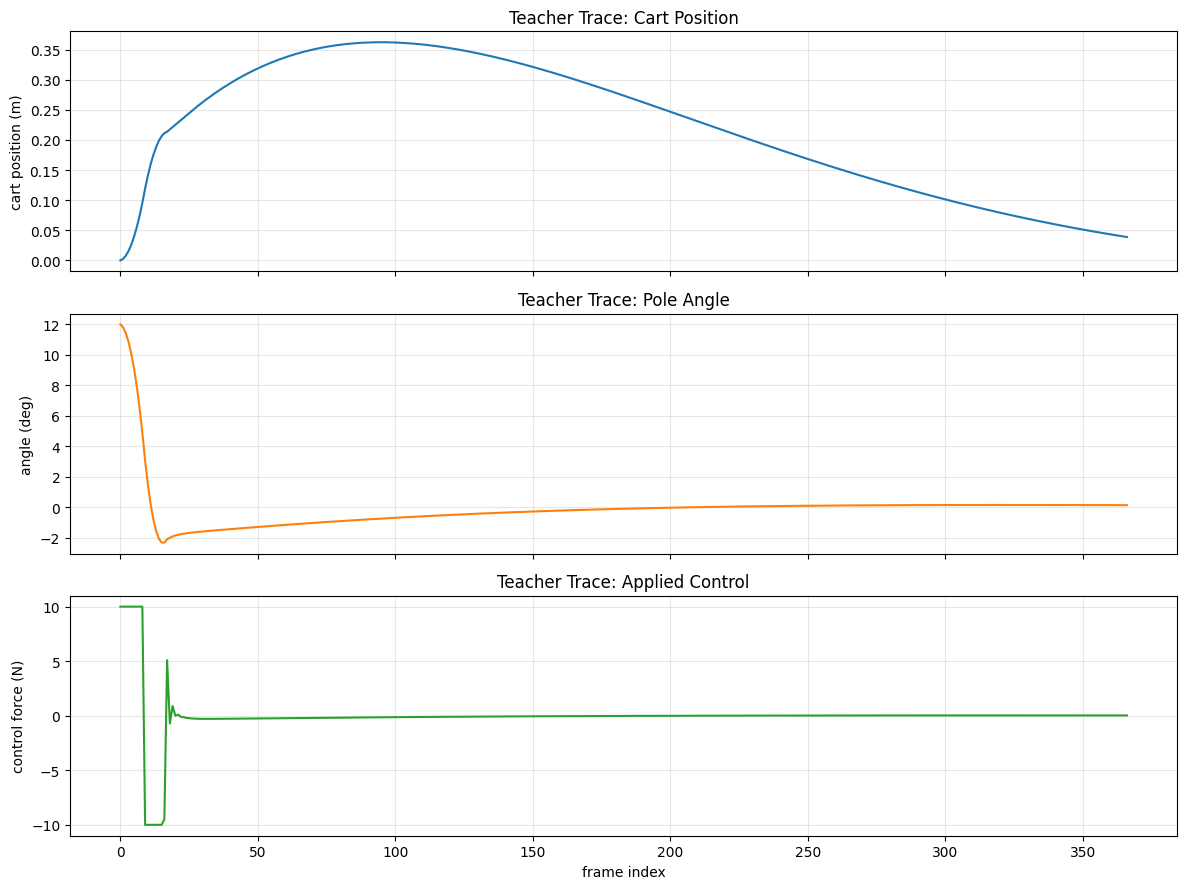

,frame_index,cart_position_m,pole_angle_deg,applied_control_force_n
0,0,0.000000,12.000000,10.0
1,1,0.002650,11.806541,10.0
2,2,0.007949,11.419612,10.0
3,3,0.015900,10.838057,10.0
4,4,0.026505,10.059583,10.0


In [3]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
frame_index = latest_trace["frame_index"].to_numpy()
position_column = str(latest_trace_schema["position_column"])
control_column = str(latest_trace_schema["control_column"])
position_label = str(latest_trace_schema["position_label"])
control_label = str(latest_trace_schema["control_label"])

axes[0].plot(frame_index, latest_trace[position_column], color="tab:blue")
axes[0].set_ylabel(position_label)
axes[0].set_title("Teacher Trace: Cart Position")
axes[0].grid(True, alpha=0.3)

axes[1].plot(frame_index, latest_trace["pole_angle_deg"], color="tab:orange")
axes[1].set_ylabel("angle (deg)")
axes[1].set_title("Teacher Trace: Pole Angle")
axes[1].grid(True, alpha=0.3)

axes[2].plot(frame_index, latest_trace[control_column], color="tab:green")
axes[2].set_xlabel("frame index")
axes[2].set_ylabel(control_label)
axes[2].set_title("Teacher Trace: Applied Control")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

latest_trace[[
    "frame_index",
    position_column,
    "pole_angle_deg",
    control_column,
]].head()

In [18]:
from sklearn.linear_model import Lasso


def load_frame_vector(frame_path: Path) -> np.ndarray:
    frame = load_raw_frame(frame_path)
    frame = pad_frame_to_target(frame, observer_frame_height_px, observer_frame_width_px)
    return frame.astype(np.float64).reshape(-1) / 255.0


def capture_controller_json_path(frames_dir: Path, metadata: dict[str, object]) -> Path:
    controller_name = metadata.get("teacher_controller_json")
    if isinstance(controller_name, str) and controller_name:
        return frames_dir / controller_name
    return frames_dir / "teacher_lqr_controller.json"


def load_teacher_controller(frames_dir: Path, metadata: dict[str, object]) -> tuple[Path, dict[str, object]]:
    controller_path = capture_controller_json_path(frames_dir, metadata)
    if not controller_path.exists():
        raise FileNotFoundError(
            f"Missing teacher controller JSON: {controller_path}. Rerun teacher_policy.py for this capture bundle."
        )
    controller = json.loads(controller_path.read_text(encoding="utf-8"))
    return controller_path, controller


def resolve_regression_control_column(bundle_trace: pd.DataFrame, bundle_trace_schema: dict[str, object]) -> str:
    if "commanded_control_force_n" in bundle_trace.columns:
        return "commanded_control_force_n"
    return str(bundle_trace_schema["control_column"])


def resolve_logged_initial_state(metadata: dict[str, object]) -> np.ndarray:
    logged_initial_state = metadata.get("logged_initial_state")
    if isinstance(logged_initial_state, list) and len(logged_initial_state) == 4:
        return np.asarray(logged_initial_state, dtype=np.float64)
    return np.array(
        [0.0, 0.0, np.deg2rad(float(metadata["initial_angle_deg"])), 0.0],
        dtype=np.float64,
    )


demo_transition_counts: list[int] = []
selected_teacher_controller_paths: list[str] = []
teacher_controller = None
teacher_controller_path = None
teacher_gain = None
nominal_a = None
nominal_b = None
training_control_column = None

x_prev_segments = []
u_prev_segments = []
x_next_segments = []
z_segments = []

for bundle in selected_demo_bundles:
    bundle_frame_dir = bundle["frame_dir"]
    bundle_metadata = bundle["metadata"]
    bundle_trace = bundle["trace"]
    bundle_frame_paths = bundle["frame_paths"]
    bundle_trace_schema = bundle["trace_schema"]
    bundle_unit_system = str(bundle["unit_system"])
    bundle_unit_value = float(bundle["unit_value"])

    if bundle_unit_system != trace_unit_system:
        raise ValueError(
            "Selected demos do not share the same trace unit system. "
            f"Expected {trace_unit_system!r}, got {bundle_unit_system!r}."
        )
    if not np.isclose(bundle_unit_value, trace_unit_value):
        raise ValueError(
            "Selected demos do not share the same unit scaling. "
            f"Expected {trace_unit_value!r}, got {bundle_unit_value!r}."
        )

    bundle_controller_path, bundle_controller = load_teacher_controller(bundle_frame_dir, bundle_metadata)
    controller_unit_system = str(bundle_controller.get("unit_system", "cartpole"))
    if controller_unit_system != bundle_unit_system:
        raise ValueError(
            "Teacher controller JSON units do not match the trace units. "
            f"Trace={bundle_unit_system!r}, controller={controller_unit_system!r}."
        )

    bundle_teacher_gain = np.asarray(bundle_controller["K"], dtype=np.float64).reshape(1, 4)
    bundle_nominal_a = np.asarray(bundle_controller["A"], dtype=np.float64)
    bundle_nominal_b = np.asarray(bundle_controller["B"], dtype=np.float64).reshape(4, 1)
    if teacher_gain is None:
        teacher_gain = bundle_teacher_gain
        teacher_controller = bundle_controller
        teacher_controller_path = bundle_controller_path
        nominal_a = bundle_nominal_a
        nominal_b = bundle_nominal_b
    elif not np.allclose(bundle_teacher_gain, teacher_gain, rtol=0.0, atol=1e-9):
        raise ValueError(
            "Selected demos do not share the same teacher-policy K. Filter the demos or regenerate them with matching teacher settings."
        )
    elif not np.allclose(bundle_nominal_a, nominal_a, rtol=0.0, atol=1e-9) or not np.allclose(
        bundle_nominal_b,
        nominal_b,
        rtol=0.0,
        atol=1e-9,
    ):
        raise ValueError(
            "Selected demos do not share the same nominal A/B matrices. Filter the demos or regenerate them with matching controller settings."
        )

    bundle_state_columns = list(bundle_trace_schema["state_columns"])
    bundle_control_column = resolve_regression_control_column(bundle_trace, bundle_trace_schema)
    if training_control_column is None:
        training_control_column = bundle_control_column
    elif bundle_control_column != training_control_column:
        raise ValueError(
            "Selected demos do not share the same control column for regression. "
            f"Expected {training_control_column!r}, got {bundle_control_column!r}."
        )

    bundle_x_next = bundle_trace[bundle_state_columns].to_numpy(dtype=np.float64)
    bundle_initial_state = resolve_logged_initial_state(bundle_metadata)
    bundle_x_prev = np.vstack([bundle_initial_state, bundle_x_next[:-1]])
    bundle_u_prev = bundle_trace[[bundle_control_column]].to_numpy(dtype=np.float64)
    bundle_z = np.stack([load_frame_vector(frame_path) for frame_path in bundle_frame_paths])

    x_prev_segments.append(bundle_x_prev)
    u_prev_segments.append(bundle_u_prev)
    x_next_segments.append(bundle_x_next)
    z_segments.append(bundle_z)
    demo_transition_counts.append(len(bundle_trace))
    selected_teacher_controller_paths.append(str(bundle_controller_path))

if teacher_gain is None or teacher_controller is None or teacher_controller_path is None or nominal_a is None or nominal_b is None:
    raise RuntimeError("No valid demos were loaded for the student-policy regression.")

state_names = list(latest_trace_schema["state_columns"])
control_units = str(latest_trace_schema["control_units"])
control_matrix_column = {
    "cartpole": "u_k_force_n",
    "scaled_steps": "u_k_scaled_steps_per_s",
    "steps": "u_k_steps_per_s",
}[trace_unit_system]

x_prev = np.vstack(x_prev_segments)
u_prev = np.vstack(u_prev_segments)
x_next = np.vstack(x_next_segments)
z_matrix = np.vstack(z_segments)
feature_mean = z_matrix.mean(axis=0)
feature_scale = z_matrix.std(axis=0)
feature_scale[feature_scale < 1e-12] = 1.0
W_without_bias = z_matrix
W_scaled = (z_matrix - feature_mean) / feature_scale
X_targets = x_next

total_transition_count = int(X_targets.shape[0])
use_stability_constraint = False
lasso_alpha = 5e-3
lasso_max_iter = 5000
lasso_tolerance = 1e-4
stability_margin = 1e-4
stability_regularization = 1e-3
stability_solver = None
stability_solver_eps = None
stability_solver_max_iters = None

A_L_nominal = nominal_a.copy()
B_L_nominal = nominal_b.copy()
nominal_predictions = x_prev @ A_L_nominal.T + u_prev @ B_L_nominal.T
residual_targets = x_next - nominal_predictions

coefficient_rows = []
observer_bias_rows = []
rmse_nominal_by_state = {}
rmse_lasso_by_state = {}
nonzero_by_state = {}

for state_index, state_name in enumerate(state_names):
    lasso_model = Lasso(
        alpha=lasso_alpha,
        fit_intercept=True,
        max_iter=lasso_max_iter,
        tol=lasso_tolerance,
    )
    lasso_model.fit(W_scaled, residual_targets[:, state_index])
    coefficient_row = lasso_model.coef_ / feature_scale
    bias_value = lasso_model.intercept_ - feature_mean @ coefficient_row
    residual_predictions = z_matrix @ coefficient_row + bias_value
    selected_predictions = nominal_predictions[:, state_index] + residual_predictions

    coefficient_rows.append(coefficient_row)
    observer_bias_rows.append(bias_value)
    rmse_nominal_by_state[state_name] = float(
        np.sqrt(np.mean((nominal_predictions[:, state_index] - X_targets[:, state_index]) ** 2))
    )
    rmse_lasso_by_state[state_name] = float(
        np.sqrt(np.mean((selected_predictions - X_targets[:, state_index]) ** 2))
    )
    nonzero_by_state[state_name] = int(np.count_nonzero(np.abs(coefficient_row) > 1e-12))

if use_stability_constraint:
    raise NotImplementedError(
        "The residual-only observer path currently exports the unconstrained nominal-plus-pixels model only."
    )

coefficient_matrix = np.vstack(coefficient_rows)
observer_bias_lasso = np.array(observer_bias_rows)
A_L_lasso = A_L_nominal.copy()
B_L_lasso = B_L_nominal.copy()
L_gain_pixels_to_state = coefficient_matrix
measurement_term = z_matrix @ L_gain_pixels_to_state.T
one_step_predictions_lasso = nominal_predictions + measurement_term + observer_bias_lasso
A_L = A_L_nominal.copy()
B_L = B_L_nominal.copy()
observer_bias = observer_bias_lasso.copy()
one_step_predictions = one_step_predictions_lasso.copy()
A_LK_lasso = A_L_lasso - B_L_lasso @ teacher_gain
A_LK_solver = None
A_LK = A_L_lasso - B_L_lasso @ teacher_gain
closed_loop_spectral_norm_lasso = float(np.linalg.norm(A_LK_lasso, ord=2))
closed_loop_max_abs_eig_lasso = float(np.max(np.abs(np.linalg.eigvals(A_LK_lasso))))
closed_loop_spectral_norm_solver = None
closed_loop_max_abs_eig_solver = None
closed_loop_norm_limit = 1.0 - stability_margin
stability_problem = None
stability_projection_applied = False
closed_loop_spectral_norm = float(np.linalg.norm(A_LK, ord=2))
closed_loop_max_abs_eig = float(np.max(np.abs(np.linalg.eigvals(A_LK))))
rmse_selected_by_state = {
    state_name: float(np.sqrt(np.mean((one_step_predictions[:, state_index] - X_targets[:, state_index]) ** 2)))
    for state_index, state_name in enumerate(state_names)
}
final_model_label = "nominal_plus_lasso_pixels"
final_matrix_label = "nominal-plus-pixels"
stability_solver_status = "disabled"
predicted_targets = None
A_LK_var = None
B_L_var = None
d_var = None
lmi_block = None
left_singular_vectors = None
singular_values = None
right_singular_vectors_t = None
clipped_singular_values = None

Theta_matrix = np.hstack([A_L, B_L, L_gain_pixels_to_state, observer_bias[:, None]])

observer_summary = pd.DataFrame(
    {
        "state": state_names,
        "rmse_nominal_model": [rmse_nominal_by_state[state_name] for state_name in state_names],
        "rmse_selected_model": [rmse_selected_by_state[state_name] for state_name in state_names],
        "selected_model": [final_model_label] * len(state_names),
        "nonzero_image_coefficients": [nonzero_by_state[state_name] for state_name in state_names],
    }
)

stability_report = {
    "enabled": bool(use_stability_constraint),
    "selected_model": final_model_label,
    "unit_system": trace_unit_system,
    "control_units": control_units,
    "teacher_controller_path": str(teacher_controller_path),
    "teacher_gain_K": teacher_gain.reshape(-1).astype(float).tolist(),
    "solver_status": stability_solver_status,
    "solver": stability_solver,
    "solver_eps": stability_solver_eps,
    "solver_max_iters": stability_solver_max_iters,
    "margin": float(stability_margin),
    "regularization": float(stability_regularization),
    "projection_applied": bool(stability_projection_applied),
    "closed_loop_spectral_norm_lasso": closed_loop_spectral_norm_lasso,
    "closed_loop_spectral_norm_solver": closed_loop_spectral_norm_solver,
    "closed_loop_spectral_norm_selected": closed_loop_spectral_norm,
    "closed_loop_max_abs_eig_lasso": closed_loop_max_abs_eig_lasso,
    "closed_loop_max_abs_eig_solver": closed_loop_max_abs_eig_solver,
    "closed_loop_max_abs_eig_selected": closed_loop_max_abs_eig,
}

demo_training_summary = pd.DataFrame(
    {
        "demo_name": training_demo_names,
        "unit_system": [trace_unit_system] * training_demo_count,
        "transitions": demo_transition_counts,
        "teacher_controller_json": selected_teacher_controller_paths,
    }
)

if latest_metadata.get("teacher_controller_json") != teacher_controller_path.name:
    latest_metadata["teacher_controller_json"] = teacher_controller_path.name
    latest_metadata_path.write_text(json.dumps(latest_metadata, indent=2, sort_keys=True), encoding="ascii")

display(Markdown("Regression input uses crop-sized binary frames padded to a shared observer geometry. No resizing is applied."))
display(Markdown(f"Teacher controller JSON: `{teacher_controller_path}`"))
display(Markdown(f"Teacher controller unit system: `{trace_unit_system}`"))
display(Markdown(unit_note))
display(Markdown(f"Observer target: `{observer_target_label}`"))
display(Markdown(f"Teacher K: `{teacher_gain.reshape(-1).tolist()}`"))
display(Markdown(f"Training demos used: `{training_demo_count}`"))
display(Markdown(f"Total transition pairs: `{total_transition_count}`"))
display(Markdown(f"Control column used for regression: `{training_control_column}`"))
display(Markdown(f"Observer geometry used for padding: `{observer_frame_height_px}x{observer_frame_width_px}`"))
display(Markdown(f"LASSO alpha: `{lasso_alpha}`"))
display(Markdown(f"Use stability constraint: `{use_stability_constraint}`"))
display(Markdown(f"Selected observer model: `{final_model_label}`"))
display(Markdown("Nominal state-control prediction is fixed from the teacher controller JSON; pixels are fit only on the true-model residual implied by the noisy logged state traces."))
display(Markdown(f"Z matrix shape: `{z_matrix.shape}`"))
display(Markdown(f"Residual target shape: `{residual_targets.shape}`"))
display(Markdown(f"L gain shape: `{L_gain_pixels_to_state.shape}`"))
display(Markdown(f"||A_L - B_L K||_2 nominal selected model: `{closed_loop_spectral_norm:.6f}`"))
display(Markdown("Stability-constrained refinement: `skipped`"))
display(demo_training_summary)
display(observer_summary)
display(Markdown(f"### A_L ({final_matrix_label})"))
display(pd.DataFrame(A_L, index=state_names, columns=state_names))
display(Markdown(f"### B_L ({final_matrix_label})"))
display(pd.DataFrame(B_L, index=state_names, columns=[control_matrix_column]))
display(Markdown(f"### d ({final_matrix_label})"))
display(pd.Series(observer_bias, index=state_names, name="bias"))

Regression input uses crop-sized binary frames padded to a shared observer geometry. No resizing is applied.

Teacher controller JSON: `/Users/imaginelenses/code/pixelsToSteps/simulation/captures/collections/crop_padded_train_20260504/demo_01_theta_m12p00_frames/teacher_lqr_controller.json`

Teacher controller unit system: `cartpole`

Nominal CartPole export: state uses meters, meters/s, radians, and radians/s; control uses newtons.

Observer target: `pixels-to-cartpole-state`

...

,cart_position_m,cart_velocity_m_s,pole_angle_rad,pole_angle_rate_rad_s
cart_position_m,1.0,0.016667,0.000000,0.000000
cart_velocity_m_s,0.0,1.000000,-0.011951,0.000000
pole_angle_rad,0.0,0.000000,1.000000,0.016667
pole_angle_rate_rad_s,0.0,0.000000,0.262927,1.000000


### B_L (nominal-plus-pixels)

,u_k_force_n
cart_position_m,0.00000
cart_velocity_m_s,0.01626
pole_angle_rad,0.00000
pole_angle_rate_rad_s,-0.02439


### d (nominal-plus-pixels)

cart_position_m          0.000000e+00
cart_velocity_m_s        0.000000e+00
pole_angle_rad           0.000000e+00
pole_angle_rate_rad_s    2.770018e-21
Name: bias, dtype: float64

In [5]:
Y_pixels = z_matrix
X_residual = residual_targets
correlation_state_names = ["pos", "vel", "angle", "angvel"]

pixel_mean = Y_pixels.mean(axis=0)
pixel_centered = Y_pixels - pixel_mean
pixel_centered_norm = np.linalg.norm(pixel_centered, axis=0)
valid_pixel_mask = pixel_centered_norm > 1e-12
constant_pixel_count = int((~valid_pixel_mask).sum())

pixel_residual_correlation_by_state: dict[str, np.ndarray] = {}
pixel_residual_correlation_rows: list[dict[str, float | int]] = []

for state_idx, state_name in enumerate(correlation_state_names):
    residual_col = X_residual[:, state_idx]
    residual_centered = residual_col - residual_col.mean()
    residual_centered_norm = float(np.linalg.norm(residual_centered))

    correlations = np.zeros(Y_pixels.shape[1], dtype=np.float64)
    if residual_centered_norm > 1e-12 and np.any(valid_pixel_mask):
        correlations[valid_pixel_mask] = (
            pixel_centered[:, valid_pixel_mask].T @ residual_centered
        ) / (pixel_centered_norm[valid_pixel_mask] * residual_centered_norm)

    abs_correlations = np.abs(correlations)
    pixel_residual_correlation_by_state[state_name] = correlations
    pixel_residual_correlation_rows.append(
        {
            "state": state_name,
            "max_abs_corr": float(abs_correlations.max(initial=0.0)),
            "pixels_abs_corr_gt_0p10": int((abs_correlations > 0.10).sum()),
            "pixels_abs_corr_gt_0p05": int((abs_correlations > 0.05).sum()),
            "pixels_abs_corr_gt_0p01": int((abs_correlations > 0.01).sum()),
            "mean_abs_corr": float(abs_correlations.mean()),
        }
    )

pixel_residual_correlation_summary = pd.DataFrame(pixel_residual_correlation_rows)

display(Markdown(f"Pixel matrix shape: `{Y_pixels.shape}`"))
display(Markdown(f"Residual matrix shape: `{X_residual.shape}`"))
display(Markdown(f"Constant pixel columns skipped in the Pearson computation: `{constant_pixel_count}`"))
display(pixel_residual_correlation_summary)

for correlation_row in pixel_residual_correlation_rows:
    display(
        Markdown(
            f"{correlation_row['state']}: max |corr| = `{correlation_row['max_abs_corr']:.6f}`, "
            f"pixels with |corr| > 0.1: `{correlation_row['pixels_abs_corr_gt_0p10']}`, "
            f"pixels with |corr| > 0.01: `{correlation_row['pixels_abs_corr_gt_0p01']}`"
        )
    )

Pixel matrix shape: `(5010, 20000)`

Residual matrix shape: `(5010, 4)`

Constant pixel columns skipped in the Pearson computation: `16156`

,state,max_abs_corr,pixels_abs_corr_gt_0p10,pixels_abs_corr_gt_0p05,pixels_abs_corr_gt_0p01,mean_abs_corr
0,pos,0.000000,0,0,0,0.000000
1,vel,0.106212,3,728,3452,0.006487
2,angle,0.000000,0,0,0,0.000000
3,angvel,0.103404,2,269,1510,0.002785


pos: max |corr| = `0.000000`, pixels with |corr| > 0.1: `0`, pixels with |corr| > 0.01: `0`

vel: max |corr| = `0.106212`, pixels with |corr| > 0.1: `3`, pixels with |corr| > 0.01: `3452`

angle: max |corr| = `0.000000`, pixels with |corr| > 0.1: `0`, pixels with |corr| > 0.01: `0`

angvel: max |corr| = `0.103404`, pixels with |corr| > 0.1: `2`, pixels with |corr| > 0.01: `1510`

In [6]:
nonzero_pixel_gain_by_state = {
    state_name: int(np.count_nonzero(np.abs(L_gain_pixels_to_state[state_index]) > 1e-12))
    for state_index, state_name in enumerate(state_names)
}
total_nonzero_pixel_gains = int(np.count_nonzero(np.abs(L_gain_pixels_to_state) > 1e-12))

bootstrap_frame_vector = load_frame_vector(first_frame_path)
bootstrap_state_from_pixels = (L_gain_pixels_to_state @ bootstrap_frame_vector) + observer_bias
bootstrap_force_from_pixels = float(-(teacher_gain @ bootstrap_state_from_pixels)[0])

display(Markdown(f"Nonzero image-gain coefficients: `{total_nonzero_pixel_gains}`"))
display(
    pd.DataFrame(
        {
            "state": list(nonzero_pixel_gain_by_state.keys()),
            "nonzero_image_coefficients": list(nonzero_pixel_gain_by_state.values()),
        }
    )
)
display(
    Markdown(
        f"Bootstrap control from the first frame with zero prior state: `{bootstrap_force_from_pixels:.6f}` {control_units}"
    )
)
if total_nonzero_pixel_gains == 0:
    display(
        Markdown(
            "**Warning:** The current observer fit ignored the image measurement entirely (`L = 0`). "
            "The one-step regression still looks good because it leans on the previous-state term, "
            "but the exported observer cannot bootstrap image-only control from pixels."
        )
    )


Nonzero image-gain coefficients: `0`

,state,nonzero_image_coefficients
0,cart_position_m,0
1,cart_velocity_m_s,0
2,pole_angle_rad,0
3,pole_angle_rate_rad_s,0


Bootstrap control from the first frame with zero prior state: `0.000000` newtons

**Warning:** The current observer fit ignored the image measurement entirely (`L = 0`). The one-step regression still looks good because it leans on the previous-state term, but the exported observer cannot bootstrap image-only control from pixels.

In [7]:
lasso_alpha_sweep = [1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
bootstrap_frame_vector = load_frame_vector(first_frame_path)
lasso_alpha_sweep_rows: list[dict[str, float | int | str]] = []
lasso_alpha_sweep_max_iter = max(lasso_max_iter, 20000)

for sweep_alpha in lasso_alpha_sweep:
    sweep_coefficient_rows = []
    sweep_bias_rows = []
    sweep_nonzero_by_state: dict[str, int] = {}
    sweep_rmse_by_state: dict[str, float] = {}

    for state_index, state_name in enumerate(state_names):
        sweep_model = Lasso(
            alpha=sweep_alpha,
            fit_intercept=True,
            max_iter=lasso_alpha_sweep_max_iter,
            tol=lasso_tolerance,
        )
        sweep_model.fit(W_scaled, residual_targets[:, state_index])
        sweep_coefficient_row = sweep_model.coef_ / feature_scale
        sweep_bias_value = sweep_model.intercept_ - feature_mean @ sweep_coefficient_row
        sweep_residual_predictions = z_matrix @ sweep_coefficient_row + sweep_bias_value
        sweep_selected_predictions = nominal_predictions[:, state_index] + sweep_residual_predictions

        sweep_coefficient_rows.append(sweep_coefficient_row)
        sweep_bias_rows.append(sweep_bias_value)
        sweep_nonzero_by_state[state_name] = int(np.count_nonzero(np.abs(sweep_coefficient_row) > 1e-12))
        sweep_rmse_by_state[state_name] = float(
            np.sqrt(np.mean((sweep_selected_predictions - X_targets[:, state_index]) ** 2))
        )

    sweep_coefficient_matrix = np.vstack(sweep_coefficient_rows)
    sweep_bias_vector = np.asarray(sweep_bias_rows, dtype=np.float64)
    sweep_total_nonzero = int(np.count_nonzero(np.abs(sweep_coefficient_matrix) > 1e-12))
    sweep_max_abs_coefficient = float(np.max(np.abs(sweep_coefficient_matrix), initial=0.0))
    sweep_bootstrap_state = sweep_coefficient_matrix @ bootstrap_frame_vector + sweep_bias_vector
    sweep_bootstrap_force = float(-(teacher_gain @ sweep_bootstrap_state)[0])

    lasso_alpha_sweep_rows.append(
        {
            "alpha": float(sweep_alpha),
            "total_nonzero_image_coefficients": sweep_total_nonzero,
            "nonzero_pos": sweep_nonzero_by_state[state_names[0]],
            "nonzero_vel": sweep_nonzero_by_state[state_names[1]],
            "nonzero_angle": sweep_nonzero_by_state[state_names[2]],
            "nonzero_angvel": sweep_nonzero_by_state[state_names[3]],
            "max_abs_coefficient": sweep_max_abs_coefficient,
            "bootstrap_force_n": sweep_bootstrap_force,
            "rmse_vel": sweep_rmse_by_state[state_names[1]],
            "rmse_angvel": sweep_rmse_by_state[state_names[3]],
        }
    )

lasso_alpha_sweep_summary = pd.DataFrame(lasso_alpha_sweep_rows)
display(Markdown(f"Plain LASSO alpha sweep on the cropped collection with max_iter=`{lasso_alpha_sweep_max_iter}`"))
display(lasso_alpha_sweep_summary)

Plain LASSO alpha sweep on the cropped collection with max_iter=`20000`

,alpha,total_nonzero_image_coefficients,nonzero_pos,nonzero_vel,nonzero_angle,nonzero_angvel,max_abs_coefficient,bootstrap_force_n,rmse_vel,rmse_angvel
0,0.00100,0,0,0,0,0,0.000000,3.033481e-19,0.000117,0.004639
1,0.00030,3,0,0,0,3,0.000198,-2.539639e-02,0.000117,0.004618
2,0.00010,68,0,0,0,68,0.002252,-7.586935e-01,0.000117,0.004276
3,0.00003,205,0,0,0,205,0.006249,-1.937945e+00,0.000117,0.003839
4,0.00001,478,0,3,0,475,0.012808,-1.922245e+00,0.000117,0.003504


In [19]:
from sklearn.linear_model import Ridge

angle_state_name = "pole_angle_rad"
angle_state_index = state_names.index(angle_state_name)
direct_angle_ridge_alpha = 0.1
direct_angle_features = z_matrix
direct_angle_targets = X_targets[:, angle_state_index]
direct_angle_bootstrap_frame_vector = load_frame_vector(first_frame_path)

direct_angle_ridge = Ridge(alpha=direct_angle_ridge_alpha, fit_intercept=True)
direct_angle_ridge.fit(direct_angle_features, direct_angle_targets)
direct_angle_predictions = direct_angle_ridge.predict(direct_angle_features)
direct_angle_r2 = float(direct_angle_ridge.score(direct_angle_features, direct_angle_targets))
direct_angle_rmse_rad = float(np.sqrt(np.mean((direct_angle_predictions - direct_angle_targets) ** 2)))
direct_angle_rmse_deg = float(np.degrees(direct_angle_rmse_rad))
direct_angle_bootstrap_rad = float(direct_angle_ridge.predict(direct_angle_bootstrap_frame_vector.reshape(1, -1))[0])
direct_angle_bootstrap_deg = float(np.degrees(direct_angle_bootstrap_rad))
bootstrap_true_angle_deg = float(np.degrees(float(latest_trace[angle_state_name].iloc[0])))

direct_angle_summary = pd.DataFrame(
    {
        "metric": [
            "ridge_alpha",
            "angle_r2",
            "angle_rmse_rad",
            "angle_rmse_deg",
            "bootstrap_true_angle_deg",
            "bootstrap_predicted_angle_deg",
        ],
        "value": [
            direct_angle_ridge_alpha,
            direct_angle_r2,
            direct_angle_rmse_rad,
            direct_angle_rmse_deg,
            bootstrap_true_angle_deg,
            direct_angle_bootstrap_deg,
        ],
    }
)

display(Markdown("Direct pixels-to-angle Ridge diagnostic"))
display(direct_angle_summary)
display(
    Markdown(
        f"Angle R^2 from pixels: `{direct_angle_r2:.6f}` | "
        f"angle RMSE: `{direct_angle_rmse_deg:.3f}` deg | "
        f"bootstrap frame angle: true `{bootstrap_true_angle_deg:+.3f}` deg, predicted `{direct_angle_bootstrap_deg:+.3f}` deg"
    )
)

Direct pixels-to-angle Ridge diagnostic

,metric,value
0,ridge_alpha,0.100000
1,angle_r2,0.989244
2,angle_rmse_rad,0.002002
3,angle_rmse_deg,0.114734
4,bootstrap_true_angle_deg,12.000000
5,bootstrap_predicted_angle_deg,11.999517


Angle R^2 from pixels: `0.989244` | angle RMSE: `0.115` deg | bootstrap frame angle: true `+12.000` deg, predicted `+12.000` deg

In [9]:
rollout_alpha_specs = [
    (1e-3, "sparse"),
    (3e-4, "medium"),
    (1e-4, "full"),
]
rollout_alpha_observer_specs: list[dict[str, object]] = []
rollout_alpha_observer_rows: list[dict[str, object]] = []
rollout_alpha_max_iter = max(lasso_max_iter, 20000)
base_observer_path = Path.cwd() / observer_json_name

for rollout_alpha, rollout_label in rollout_alpha_specs:
    rollout_coefficient_rows = []
    rollout_bias_rows = []
    rollout_nonzero_by_state: dict[str, int] = {}
    rollout_rmse_by_state: dict[str, float] = {}

    for state_index, state_name in enumerate(state_names):
        rollout_lasso_model = Lasso(
            alpha=rollout_alpha,
            fit_intercept=True,
            max_iter=rollout_alpha_max_iter,
            tol=lasso_tolerance,
        )
        rollout_lasso_model.fit(W_scaled, residual_targets[:, state_index])
        rollout_coefficient_row = rollout_lasso_model.coef_ / feature_scale
        rollout_bias_value = rollout_lasso_model.intercept_ - feature_mean @ rollout_coefficient_row
        rollout_residual_predictions = z_matrix @ rollout_coefficient_row + rollout_bias_value
        rollout_selected_predictions = nominal_predictions[:, state_index] + rollout_residual_predictions

        rollout_coefficient_rows.append(rollout_coefficient_row)
        rollout_bias_rows.append(rollout_bias_value)
        rollout_nonzero_by_state[state_name] = int(np.count_nonzero(np.abs(rollout_coefficient_row) > 1e-12))
        rollout_rmse_by_state[state_name] = float(
            np.sqrt(np.mean((rollout_selected_predictions - X_targets[:, state_index]) ** 2))
        )

    rollout_coefficient_matrix = np.vstack(rollout_coefficient_rows)
    rollout_bias_vector = np.asarray(rollout_bias_rows, dtype=np.float64)
    rollout_total_nonzero = int(np.count_nonzero(np.abs(rollout_coefficient_matrix) > 1e-12))
    rollout_bootstrap_state = rollout_coefficient_matrix @ bootstrap_frame_vector + rollout_bias_vector
    rollout_bootstrap_force = float(-(teacher_gain @ rollout_bootstrap_state)[0])
    alpha_slug = f"{rollout_alpha:.0e}".replace("-0", "-")
    rollout_observer_path = base_observer_path.with_name(
        f"{base_observer_path.stem}_{rollout_label}_alpha_{alpha_slug}{base_observer_path.suffix}"
    )

    rollout_observer_payload = {
        "anchor_frame_dir": str(latest_frame_dir),
        "source_frame_dirs": training_demo_dirs,
        "source_trace_csv": latest_trace_path.name,
        "rollout_model": rollout_model,
        "demo_count": int(training_demo_count),
        "demo_transition_counts": demo_transition_counts,
        "total_transition_pairs": int(total_transition_count),
        "teacher_controller_json": str(teacher_controller_path),
        "teacher_gain_K": teacher_gain.reshape(-1).astype(float).tolist(),
        "unit_system": trace_unit_system,
        "observer_target": observer_target_label,
        "frame_height_px": int(latest_metadata["frame_height_px"]),
        "frame_width_px": int(latest_metadata["frame_width_px"]),
        "frame_rate_hz": float(latest_metadata["frame_rate_hz"]),
        "state_order": state_names,
        "measurement_description": "flattened binary frame z_{k+1}",
        "control_units": control_units,
        "preprocessing": "cropped vertically to the pole-plus-track region, resized back to the capture resolution",
        "lasso_alpha": float(rollout_alpha),
        "lasso_max_iter": int(rollout_alpha_max_iter),
        "lasso_tolerance": float(lasso_tolerance),
        "use_stability_constraint": False,
        "selected_model": f"nominal_plus_lasso_pixels_{rollout_label}",
        "nonzero_image_coefficients": rollout_total_nonzero,
        "A_L": A_L_nominal.tolist(),
        "B_L": B_L_nominal.tolist(),
        "L": rollout_coefficient_matrix.tolist(),
        "d": rollout_bias_vector.tolist(),
    }
    rollout_observer_path.write_text(json.dumps(rollout_observer_payload, indent=2), encoding="utf-8")

    rollout_alpha_observer_specs.append(
        {
            "label": rollout_label,
            "alpha": float(rollout_alpha),
            "observer_json_path": rollout_observer_path,
            "total_nonzero_image_coefficients": rollout_total_nonzero,
            "bootstrap_force_n": rollout_bootstrap_force,
            "nonzero_by_state": rollout_nonzero_by_state,
            "rmse_by_state": rollout_rmse_by_state,
        }
    )
    rollout_alpha_observer_rows.append(
        {
            "label": rollout_label,
            "alpha": float(rollout_alpha),
            "observer_json": rollout_observer_path.name,
            "total_nonzero_image_coefficients": rollout_total_nonzero,
            "nonzero_angvel": rollout_nonzero_by_state[state_names[3]],
            "bootstrap_force_n": rollout_bootstrap_force,
            "rmse_angvel": rollout_rmse_by_state[state_names[3]],
        }
    )

rollout_alpha_observer_summary = pd.DataFrame(rollout_alpha_observer_rows)
display(Markdown(f"Exported rollout-test observers with max_iter=`{rollout_alpha_max_iter}`"))
display(rollout_alpha_observer_summary)

Exported rollout-test observers with max_iter=`20000`

,label,alpha,observer_json,total_nonzero_image_coefficients,nonzero_angvel,bootstrap_force_n,rmse_angvel
0,sparse,0.0010,learned_pixels_to_cartpole_observer_sparse_alp...,0,0,3.033481e-19,0.004639
1,medium,0.0003,learned_pixels_to_cartpole_observer_medium_alp...,3,3,-2.539639e-02,0.004618
2,full,0.0001,learned_pixels_to_cartpole_observer_full_alpha...,68,68,-7.586935e-01,0.004276


In [10]:
from sklearn.linear_model import Ridge

ridge_alpha = 1.0
sigma_obs = 0.01
ridge_noise_seed = 0
ridge_noise_rng = np.random.default_rng(ridge_noise_seed)

ridge_residual_targets = residual_targets + ridge_noise_rng.normal(
    0.0,
    sigma_obs,
    size=residual_targets.shape,
)
ridge_model = Ridge(alpha=ridge_alpha, fit_intercept=True)
ridge_model.fit(W_scaled, ridge_residual_targets)

ridge_coefficients_scaled = np.asarray(ridge_model.coef_, dtype=np.float64)
if ridge_coefficients_scaled.ndim == 1:
    ridge_coefficients_scaled = ridge_coefficients_scaled.reshape(1, -1)
ridge_coefficient_matrix = ridge_coefficients_scaled / feature_scale[np.newaxis, :]
ridge_observer_bias = np.asarray(ridge_model.intercept_, dtype=np.float64) - feature_mean @ ridge_coefficient_matrix.T
ridge_residual_predictions = z_matrix @ ridge_coefficient_matrix.T + ridge_observer_bias
ridge_one_step_predictions = nominal_predictions + ridge_residual_predictions
ridge_rmse_by_state = {
    state_name: float(np.sqrt(np.mean((ridge_one_step_predictions[:, state_index] - X_targets[:, state_index]) ** 2)))
    for state_index, state_name in enumerate(state_names)
}
ridge_nonzero_pixel_gain_by_state = {
    state_name: int(np.count_nonzero(np.abs(ridge_coefficient_matrix[state_index]) > 1e-12))
    for state_index, state_name in enumerate(state_names)
}
ridge_total_nonzero_pixel_gains = int(np.count_nonzero(np.abs(ridge_coefficient_matrix) > 1e-12))
ridge_l_max_abs = float(np.max(np.abs(ridge_coefficient_matrix)))

ridge_bootstrap_frame_vector = load_frame_vector(first_frame_path)
ridge_bootstrap_state_from_pixels = ridge_coefficient_matrix @ ridge_bootstrap_frame_vector + ridge_observer_bias
ridge_bootstrap_force_from_pixels = float(-(teacher_gain @ ridge_bootstrap_state_from_pixels)[0])

ridge_observer_json_path = Path.cwd() / "diagnostic_ridge_pixels_to_cartpole_observer.json"
ridge_observer_payload = {
    "anchor_frame_dir": str(latest_frame_dir),
    "source_frame_dirs": training_demo_dirs,
    "source_trace_csv": latest_trace_path.name,
    "rollout_model": rollout_model,
    "demo_count": int(training_demo_count),
    "demo_transition_counts": demo_transition_counts,
    "total_transition_pairs": int(total_transition_count),
    "teacher_controller_json": str(teacher_controller_path),
    "teacher_gain_K": teacher_gain.reshape(-1).astype(float).tolist(),
    "unit_system": trace_unit_system,
    "observer_target": observer_target_label,
    "frame_height_px": int(latest_metadata["frame_height_px"]),
    "frame_width_px": int(latest_metadata["frame_width_px"]),
    "frame_rate_hz": float(latest_metadata["frame_rate_hz"]),
    "state_order": state_names,
    "measurement_description": "flattened binary frame z_{k+1}",
    "control_units": control_units,
    "preprocessing": "none",
    "selected_model": "nominal_plus_ridge_pixels_diagnostic",
    "ridge_alpha": float(ridge_alpha),
    "sigma_obs": float(sigma_obs),
    "ridge_noise_seed": int(ridge_noise_seed),
    "nonzero_image_coefficients": ridge_total_nonzero_pixel_gains,
    "A_L": A_L_nominal.tolist(),
    "B_L": B_L_nominal.tolist(),
    "L": ridge_coefficient_matrix.tolist(),
    "d": ridge_observer_bias.tolist(),
}
ridge_observer_json_path.write_text(json.dumps(ridge_observer_payload, indent=2), encoding="utf-8")

ridge_summary = pd.DataFrame(
    {
        "state": state_names,
        "rmse_nominal_model": [rmse_nominal_by_state[state_name] for state_name in state_names],
        "rmse_ridge_model": [ridge_rmse_by_state[state_name] for state_name in state_names],
        "nonzero_ridge_image_coefficients": [ridge_nonzero_pixel_gain_by_state[state_name] for state_name in state_names],
    }
)

display(Markdown(f"Ridge alpha: `{ridge_alpha}`"))
display(Markdown(f"Injected residual observation noise sigma: `{sigma_obs}`"))
display(Markdown(f"Ridge L max abs: `{ridge_l_max_abs:.6e}`"))
display(Markdown(f"Ridge nonzero image-gain coefficients: `{ridge_total_nonzero_pixel_gains}`"))
display(Markdown(f"Ridge bootstrap control from first frame: `{ridge_bootstrap_force_from_pixels:.6f}` {control_units}"))
display(ridge_summary)
display(Markdown(f"Saved Ridge diagnostic observer JSON to `{ridge_observer_json_path}`"))

Ridge alpha: `1.0`

Injected residual observation noise sigma: `0.01`

Ridge L max abs: `3.892093e-02`

Ridge nonzero image-gain coefficients: `15376`

Ridge bootstrap control from first frame: `-0.899844` newtons

,state,rmse_nominal_model,rmse_ridge_model,nonzero_ridge_image_coefficients
0,cart_position_m,4.165959e-17,0.002666,3844
1,cart_velocity_m_s,1.170035e-04,0.002614,3844
2,pole_angle_rad,4.116654e-17,0.003003,3844
3,pole_angle_rate_rad_s,4.638810e-03,0.003807,3844


Saved Ridge diagnostic observer JSON to `/Users/imaginelenses/code/pixelsToSteps/simulation/python/diagnostic_ridge_pixels_to_cartpole_observer.json`

In [11]:
observer_json_path = Path.cwd() / observer_json_name
observer_payload = {
    "anchor_frame_dir": str(latest_frame_dir),
    "source_frame_dirs": training_demo_dirs,
    "source_trace_csv": latest_trace_path.name,
    "rollout_model": rollout_model,
    "demo_count": int(training_demo_count),
    "demo_transition_counts": demo_transition_counts,
    "total_transition_pairs": int(total_transition_count),
    "teacher_controller_json": str(teacher_controller_path),
    "teacher_gain_K": teacher_gain.reshape(-1).astype(float).tolist(),
    "unit_system": trace_unit_system,
    "observer_target": observer_target_label,
    "frame_height_px": int(latest_metadata["frame_height_px"]),
    "frame_width_px": int(latest_metadata["frame_width_px"]),
    "frame_rate_hz": float(latest_metadata["frame_rate_hz"]),
    "state_order": state_names,
    "measurement_description": "flattened binary frame z_{k+1}",
    "control_units": control_units,
    "preprocessing": "none",
    "lasso_alpha": float(lasso_alpha),
    "lasso_max_iter": int(lasso_max_iter),
    "lasso_tolerance": float(lasso_tolerance),
    "use_stability_constraint": bool(use_stability_constraint),
    "selected_model": final_model_label,
    "nonzero_image_coefficients": int(np.count_nonzero(np.abs(L_gain_pixels_to_state) > 1e-12)),
    "stability_constraint": {
        "enabled": stability_report["enabled"],
        "solver": stability_report["solver"],
        "solver_status": stability_report["solver_status"],
        "solver_eps": stability_report["solver_eps"],
        "solver_max_iters": stability_report["solver_max_iters"],
        "margin": stability_report["margin"],
        "regularization": stability_report["regularization"],
        "projection_applied": stability_report["projection_applied"],
        "closed_loop_spectral_norm_lasso": stability_report["closed_loop_spectral_norm_lasso"],
        "closed_loop_spectral_norm_solver": stability_report["closed_loop_spectral_norm_solver"],
        "closed_loop_spectral_norm_selected": stability_report["closed_loop_spectral_norm_selected"],
        "closed_loop_max_abs_eig_lasso": stability_report["closed_loop_max_abs_eig_lasso"],
        "closed_loop_max_abs_eig_solver": stability_report["closed_loop_max_abs_eig_solver"],
        "closed_loop_max_abs_eig_selected": stability_report["closed_loop_max_abs_eig_selected"],
    },
    "A_L": A_L.tolist(),
    "B_L": B_L.tolist(),
    "L": L_gain_pixels_to_state.tolist(),
    "d": observer_bias.tolist(),
    "A_L_lasso": A_L_lasso.tolist(),
    "B_L_lasso": B_L_lasso.tolist(),
    "d_lasso": observer_bias_lasso.tolist(),
}
observer_json_path.write_text(json.dumps(observer_payload, indent=2), encoding="utf-8")

display(Markdown(f"Saved learned observer JSON to `{observer_json_path}`"))
display(Markdown(f"JSON size: `{observer_json_path.stat().st_size}` bytes"))

Saved learned observer JSON to `/Users/imaginelenses/code/pixelsToSteps/simulation/python/learned_pixels_to_cartpole_observer.json`

JSON size: `885808` bytes

In [21]:
hybrid_theta_pixel_blend_weight = 0.7
hybrid_theta_dot_blend_weight = 0.1
hybrid_cart_pixel_blend_weight = 0.8
hybrid_observer_json_path = Path.cwd() / "hybrid_pixels_to_cartpole_observer_theta_blend_0p7.json"
hybrid_zero_l = np.zeros((len(state_names), z_matrix.shape[1]), dtype=np.float64)
hybrid_zero_d = np.zeros(len(state_names), dtype=np.float64)
hybrid_theta_pixel_coefficients = np.asarray(direct_angle_ridge.coef_, dtype=np.float64).reshape(-1)
hybrid_theta_pixel_bias = float(direct_angle_ridge.intercept_)

hybrid_observer_payload = {
    "anchor_frame_dir": str(latest_frame_dir),
    "source_frame_dirs": training_demo_dirs,
    "source_trace_csv": latest_trace_path.name,
    "rollout_model": rollout_model,
    "demo_count": int(training_demo_count),
    "demo_transition_counts": demo_transition_counts,
    "total_transition_pairs": int(total_transition_count),
    "teacher_controller_json": str(teacher_controller_path),
    "teacher_gain_K": teacher_gain.reshape(-1).astype(float).tolist(),
    "unit_system": trace_unit_system,
    "observer_target": "hybrid_nominal_dynamics_plus_direct_pixel_angle",
    "frame_height_px": int(observer_frame_height_px),
    "frame_width_px": int(observer_frame_width_px),
    "frame_rate_hz": float(latest_metadata["frame_rate_hz"]),
    "state_order": state_names,
    "measurement_description": "flattened padded binary frame z_{k+1}",
    "control_units": control_units,
    "preprocessing": preprocessing_description,
    "selected_model": "hybrid_nominal_plus_ridge_theta_blend",
    "A_L": A_L_nominal.tolist(),
    "B_L": B_L_nominal.tolist(),
    "L": hybrid_zero_l.tolist(),
    "d": hybrid_zero_d.tolist(),
    "theta_pixel_model": "ridge_direct_angle",
    "theta_pixel_coefficients": hybrid_theta_pixel_coefficients.astype(float).tolist(),
    "theta_pixel_bias": hybrid_theta_pixel_bias,
    "theta_pixel_blend_weight": float(hybrid_theta_pixel_blend_weight),
    "theta_dot_blend_weight": float(hybrid_theta_dot_blend_weight),
    "cart_pixel_blend_weight": float(hybrid_cart_pixel_blend_weight),
    "theta_pixel_ridge_alpha": float(direct_angle_ridge_alpha),
    "theta_pixel_r2": float(direct_angle_r2),
    "theta_pixel_rmse_deg": float(direct_angle_rmse_deg),
    "theta_pixel_bootstrap_true_angle_deg": float(bootstrap_true_angle_deg),
    "theta_pixel_bootstrap_predicted_angle_deg": float(direct_angle_bootstrap_deg),
    "nonzero_image_coefficients": 0,
    "nonzero_theta_pixel_coefficients": int(np.count_nonzero(np.abs(hybrid_theta_pixel_coefficients) > 1e-12)),
}
hybrid_observer_json_path.write_text(json.dumps(hybrid_observer_payload, indent=2), encoding="utf-8")

hybrid_observer_summary = pd.DataFrame(
    {
        "metric": [
            "observer_json",
            "frame_geometry",
            "theta_pixel_blend_weight",
            "theta_dot_blend_weight",
            "cart_pixel_blend_weight",
            "theta_pixel_r2",
            "theta_pixel_rmse_deg",
            "bootstrap_true_angle_deg",
            "bootstrap_predicted_angle_deg",
            "nonzero_theta_pixel_coefficients",
        ],
        "value": [
            hybrid_observer_json_path.name,
            f"{observer_frame_height_px}x{observer_frame_width_px}",
            hybrid_theta_pixel_blend_weight,
            hybrid_theta_dot_blend_weight,
            hybrid_cart_pixel_blend_weight,
            float(direct_angle_r2),
            float(direct_angle_rmse_deg),
            float(bootstrap_true_angle_deg),
            float(direct_angle_bootstrap_deg),
            int(np.count_nonzero(np.abs(hybrid_theta_pixel_coefficients) > 1e-12)),
        ],
    }
)

display(Markdown("Exported hybrid nominal-dynamics plus direct pixel-angle observer"))
display(hybrid_observer_summary)
display(Markdown(f"Saved hybrid observer JSON to `{hybrid_observer_json_path}`"))


Exported hybrid nominal-dynamics plus direct pixel-angle observer

,metric,value
0,observer_json,hybrid_pixels_to_cartpole_observer_theta_blend...
1,frame_geometry,117x600
2,theta_pixel_blend_weight,0.7
3,theta_dot_blend_weight,0.1
4,cart_pixel_blend_weight,0.8
5,theta_pixel_r2,0.989244
6,theta_pixel_rmse_deg,0.114734
7,bootstrap_true_angle_deg,12.0
8,bootstrap_predicted_angle_deg,11.999517
9,nonzero_theta_pixel_coefficients,12952


Saved hybrid observer JSON to `/Users/imaginelenses/code/pixelsToSteps/simulation/python/hybrid_pixels_to_cartpole_observer_theta_blend_0p7.json`